In [33]:
import wandb
import pandas as pd
import os
import json

wandb.login()
api = wandb.Api()

In [ ]:
run_names = [
    "73M_2025.08.24_09.01",
    "130M_2025.08.24_09.01",
    "j2tkor55",
    "xjdm3gvb",
    "5ffbr0lc",
    "n5v1hegt",
]

In [48]:
for run_name in run_names:
    
    parquet_path = f"plots/datapoints/{run_name}.parquet"
    config_path= f"plots/datapoints/{run_name}.json"


    if not os.path.exists(parquet_path):
        my_run = api.run(f"samdauncey-eth-z-rich/training_random_base_model/runs/{run_name}")
        history = my_run.scan_history()
        df = pd.DataFrame(history)
        df.to_parquet(parquet_path)

        with open(config_path, "w") as f:
            json.dump(my_run.config, f, indent=4)

    else:
        df = pd.read_parquet(parquet_path)

df.head()


,_step,val_gating_loss,all_bytes_elapsed,val_true_downsample_rate,val_rate_consistency_loss,non_padding_bytes,_runtime,val_ar_loss,pre_clip_grad_norm,true_downsample_rate,...,non_padding_bytes_elapsed,early_ar_loss,rate_consistency_loss,model_flops_utilization,val_late_ar_loss,val_early_ar_loss,val_downsample_rate_target,val_mean_selected_action_ce,_timestamp,batch_wallclock_time
0,0,-0.004072,262144.0,0.25,0.0,262144,17.326676,9.005247,59.75,0.25,...,262144.0,6.487809,0,0.075919,9.005247,6.490944,0.25,0.5625,1.755493e+09,2.070425
1,1,NaN,524288.0,NaN,NaN,262144,19.465328,NaN,59.50,0.25,...,524288.0,6.488326,0,0.036973,NaN,NaN,NaN,NaN,1.755493e+09,4.251344
2,2,NaN,786432.0,NaN,NaN,262144,24.728602,NaN,114.00,0.25,...,786432.0,5.326530,0,0.073597,NaN,NaN,NaN,NaN,1.755493e+09,2.135741
3,3,NaN,1048576.0,NaN,NaN,262144,27.071715,NaN,114.50,0.25,...,1048576.0,5.338043,0,0.029877,NaN,NaN,NaN,NaN,1.755493e+09,5.261064
4,4,NaN,1310720.0,NaN,NaN,262144,30.078166,NaN,72.50,0.25,...,1310720.0,5.766067,0,0.067148,NaN,NaN,NaN,NaN,1.755493e+09,2.340864


In [41]:
val_steps = df["val_true_downsample_rate"].notna()
df_val = df[
    val_steps
]

df_val.head()

,val_true_downsample_rate,ar_loss,all_bytes,val_total_loss,val_in_context_learning_score,model_flops_utilization,_runtime,val_late_ar_loss,val_ar_loss,early_ar_loss,...,val_gating_loss,all_bytes_elapsed,val_downsample_rate_target,non_padding_bytes,gating_loss,batch_wallclock_time,learning_rate,true_downsample_rate,val_mean_selected_action_ce,flops
0,0.593994,9.983297,65536,10.154173,-0.344841,0.065317,10.856865,10.763935,9.990622,6.883437,...,-0.074120,65536.0,0.25,65536,-0.063671,0.831405,0.000200,0.578125,0.588379,3.388602e+13
800,0.241150,4.186058,65536,4.221803,-0.018277,0.076621,366.961863,4.540542,4.178712,2.753381,...,0.042897,52494336.0,0.25,65536,0.055810,0.380404,0.000410,0.242188,0.287109,1.818771e+13
1600,0.256958,2.825149,65536,2.765026,0.063144,0.082096,735.904194,2.844413,2.770273,2.534347,...,-0.005451,104923136.0,0.25,65536,-0.003145,0.389106,0.000619,0.263672,0.109375,1.993318e+13
2400,0.252930,2.141927,65536,2.119657,0.063097,0.081281,1116.815933,2.118493,2.123461,2.165302,...,-0.003882,157351936.0,0.25,65536,-0.000798,0.372316,0.000829,0.253906,0.039352,1.888372e+13
3200,0.254761,1.693518,65536,1.702938,0.024347,0.070991,1491.645153,1.682747,1.708118,1.794701,...,-0.005296,209780736.0,0.25,65536,-0.007676,0.442363,0.001039,0.250000,0.017052,1.959604e+13


In [10]:
import seaborn as sns

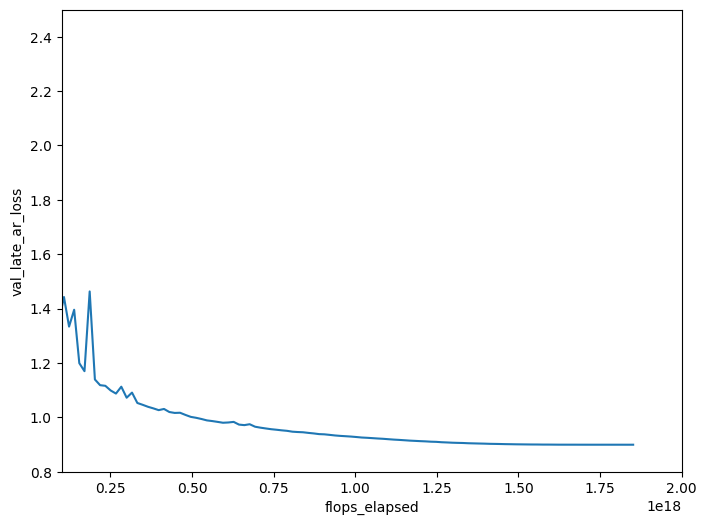

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=df_val,
    x="flops_elapsed",
    y="val_late_ar_loss"
)

plt.ylim(0.8, 2.5)
plt.xlim(1e17, 2e18)

plt.show()